# SME DataPrep Python examples

This notebook illustrates the package with the Titanic training dataset stored in `data/titanic/train.csv`. The target variable is `Survived`, where `1` means the passenger survived and `0` means they did not.

## Goal

Use the required preprocessing functions on a real mixed-type dataset: numerical variables, categorical variables, and one binary target for AUC.

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd

# Allows this notebook to import the local package before it is installed.
sys.path.insert(0, str(Path.cwd() / "package"))

from dataprepkit import (
    DataPrepDataset,
    association_matrix,
    attribute_metrics,
    discretize_dataset_equal_frequency,
    discretize_dataset_equal_width,
    filter_variables,
    normalize_dataset,
    plot_association_matrix,
    plot_auc_values,
    standardize_dataset,
)

## Data

The Titanic training file has passenger-level information and the binary outcome `Survived`. For this first example, we keep a focused set of variables so every function is easy to interpret.

In [2]:
data_path = Path("data/titanic/train.csv")
raw_data = pd.read_csv(data_path)

analysis_data = raw_data[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]].copy()

# Pclass is numeric in the CSV, but conceptually it is a passenger class category.
analysis_data["Pclass"] = analysis_data["Pclass"].astype("category")
analysis_data["Survived"] = analysis_data["Survived"].astype(int)

dataset = DataPrepDataset(analysis_data, target="Survived")
analysis_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
analysis_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    str     
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  889 non-null    str     
dtypes: category(1), float64(2), int64(3), str(2)
memory usage: 49.7 KB


## Steps

### 1. Attribute metrics

Numerical attributes receive variance and AUC. Categorical attributes receive entropy.

In [4]:
metrics = attribute_metrics(analysis_data, target="Survived", positive_class=1)
metrics

,attribute,metric,value
0,Pclass,entropy,1.439321
1,Sex,entropy,0.936205
2,Age,variance,210.723580
3,Age,auc,0.469112
4,SibSp,variance,1.214678
5,SibSp,auc,0.543162
6,Parch,variance,0.648999
7,Parch,auc,0.561217
8,Fare,variance,2466.665312
9,Fare,auc,0.692122


### 2. Equal-width and equal-frequency discretization

The functions can transform one variable or the selected numerical columns of a dataset.

In [5]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]

equal_width_data = discretize_dataset_equal_width(analysis_data[numeric_features], bins=4)
equal_frequency_data = discretize_dataset_equal_frequency(analysis_data[numeric_features], bins=4)

equal_width_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_1,bin_1,bin_1
1,bin_2,bin_1,bin_1,bin_1
2,bin_2,bin_1,bin_1,bin_1
3,bin_2,bin_1,bin_1,bin_1
4,bin_2,bin_1,bin_1,bin_1


In [6]:
equal_frequency_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_3,bin_1,bin_1
1,bin_3,bin_3,bin_1,bin_4
2,bin_2,bin_1,bin_1,bin_2
3,bin_3,bin_3,bin_1,bin_4
4,bin_3,bin_1,bin_1,bin_2


### 3. Normalization and standardization

Only numerical feature columns are transformed. The target is kept unchanged.

In [7]:
normalized_features = normalize_dataset(analysis_data[numeric_features])
standardized_features = standardize_dataset(analysis_data[numeric_features])

normalized_features.head()

,Age,SibSp,Parch,Fare
0,0.271174,0.125,0.0,0.014151
1,0.472229,0.125,0.0,0.139136
2,0.321438,0.000,0.0,0.015469
3,0.434531,0.125,0.0,0.103644
4,0.434531,0.000,0.0,0.015713


In [8]:
standardized_features.head()

,Age,SibSp,Parch,Fare
0,-0.530377,0.432793,-0.473674,-0.502445
1,0.571831,0.432793,-0.473674,0.786845
2,-0.254825,-0.474545,-0.473674,-0.488854
3,0.365167,0.432793,-0.473674,0.420730
4,0.365167,-0.474545,-0.473674,-0.486337


### 4. Variable filtering

This example keeps variables whose AUC is at least 0.55. The threshold is intentionally modest because a single Titanic feature is not expected to perfectly separate survival.

In [9]:
filtered_by_auc = filter_variables(
    analysis_data,
    metric="auc",
    threshold=0.55,
    target="Survived",
    positive_class=1,
)
filtered_by_auc.head()

,Parch,Fare,Survived
0,0,7.2500,0
1,0,71.2833,1
2,0,7.9250,1
3,0,53.1000,1
4,0,8.0500,0


### 5. Pairwise association matrix

Numerical-numerical pairs use Pearson correlation. Categorical-categorical pairs use mutual information. Mixed-type pairs are marked as missing values.

In [10]:
association_features = analysis_data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
matrix = association_matrix(association_features)
matrix

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Pclass,1.439321,0.013710,NaN,NaN,NaN,NaN,0.102142
Sex,0.013710,0.936205,NaN,NaN,NaN,NaN,0.010617
Age,NaN,NaN,1.000000,-0.308247,-0.189119,0.096067,NaN
SibSp,NaN,NaN,-0.308247,1.000000,0.414838,0.159651,NaN
Parch,NaN,NaN,-0.189119,0.414838,1.000000,0.216225,NaN
Fare,NaN,NaN,0.096067,0.159651,0.216225,1.000000,NaN
Embarked,0.102142,0.010617,NaN,NaN,NaN,NaN,1.096869


## Checks

The following cells generate the required visualizations for AUC and the association matrix.

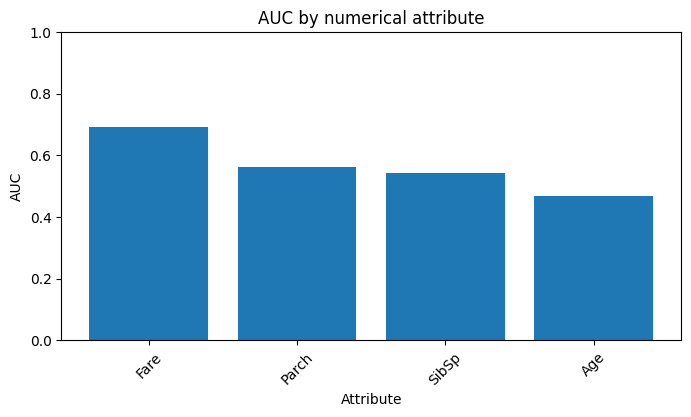

In [11]:
plot_auc_values(analysis_data, target="Survived", positive_class=1);

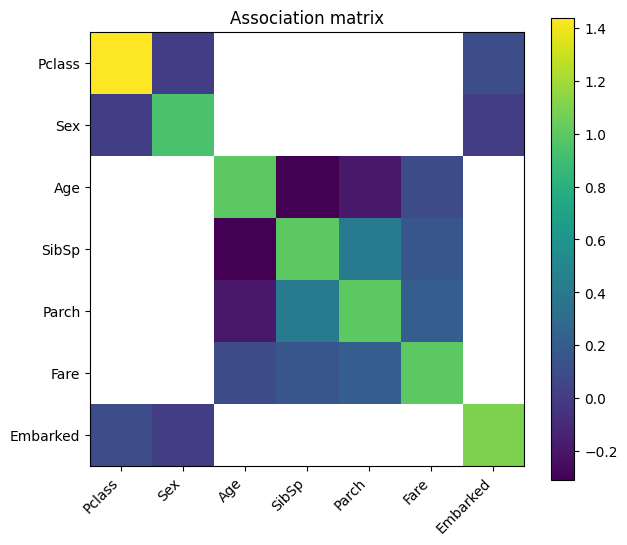

In [12]:
plot_association_matrix(matrix);

## Next Steps

When the second dataset is added, repeat the same workflow in a new section: load the data, identify the binary target, choose meaningful numerical/categorical variables, and show the same functions again.